
# Exercício Prático Avaliativo — Inferência Bayesiana

## Cenário escolhido: B — Ciência de Dados e Classificação Probabilística

Esta atividade tem como objetivo aplicar os conceitos de probabilidade condicional, o Teorema de Bayes e o impacto de dados desbalanceados em cenários reais de engenharia. Utilizaremos como fundação o notebook de estudos da disciplina (baseado no ecossistema de dados da UFMG).



## A. Contexto do problema

O conjunto de teste possui uma base desbalanceada: **1 em cada 2.000 transações** é uma fraude.

Assim, a probabilidade de fraude é:

$$
P(F) = \frac{1}{2000} = 0{,}0005
$$

A probabilidade de uma transação normal é:

$$
P(N) = 1 - P(F) = 0{,}9995
$$

O classificador possui:

- Sensibilidade / Recall:  

$$
P(Positivo \mid Fraude) = 0{,}98
$$

- Taxa de falso positivo:  

$$
P(Positivo \mid Normal) = 0{,}01
$$




## B. Fundamentação teórica

Queremos calcular:

$$
P(Fraude \mid Positivo)
$$

Pelo Teorema de Bayes:

$$
P(Fraude \mid Positivo) = \frac{P(Positivo \mid Fraude) \cdot P(Fraude)}{P(Positivo)}
$$

Pela Lei da Probabilidade Total, a probabilidade de o modelo acusar positivo é:

$$
P(Positivo) = P(Positivo \mid Fraude) \cdot P(Fraude) + P(Positivo \mid Normal) \cdot P(Normal)
$$

Substituindo:

$$
P(Fraude \mid Positivo) = \frac{P(Positivo \mid Fraude) \cdot P(Fraude)}{P(Positivo \mid Fraude) \cdot P(Fraude) + P(Positivo \mid Normal) \cdot P(Normal)}
$$


In [11]:
# Bibliotecas utilizadas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Parâmetros do problema
prob_fraude = 1 / 2000          # P(Fraude)
prob_normal = 1 - prob_fraude   # P(Normal)

sensibilidade = 0.98            # P(Positivo | Fraude)
taxa_falso_positivo = 0.01      # P(Positivo | Normal)

# fórmula de Bayes
prob_positivo = (sensibilidade * prob_fraude) + (taxa_falso_positivo * prob_normal)
vpp = (sensibilidade * prob_fraude) / prob_positivo

print(f"P(Fraude): {prob_fraude:.6f}")
print(f"P(Normal): {prob_normal:.6f}")
print(f"P(Positivo): {prob_positivo:.6f}")
print(f"VPP / Precision = P(Fraude | Positivo): {vpp:.6f}")
print(f"VPP / Precision em porcentagem: {vpp * 100:.2f}%")

P(Fraude): 0.000500
P(Normal): 0.999500
P(Positivo): 0.010485
VPP / Precision = P(Fraude | Positivo): 0.046733
VPP / Precision em porcentagem: 4.67%



## C. Resultado

O resultado obtido foi aproximadamente:

$$
P(Fraude \mid Positivo) \approx 0{,}0467
$$

Ou seja:

$$
P(Fraude \mid Positivo) \approx 4{,}67\%
$$

Mesmo com uma sensibilidade de 98% e uma especificidade de 99%, a probabilidade de uma transação classificada como suspeita realmente ser fraude é baixa. Isso acontece porque a fraude é um evento muito raro na base de dados.



## D. Demonstração numérica com uma base simulada

Vamos supor uma base com 2.000.000 de transações.

Como a proporção real de fraudes é de 1 em 2.000, espera-se:

$$
\frac{2.000.000}{2.000} = 1.000
$$

transações fraudulentas reais.


In [13]:
# Simulação determinística usando uma base hipotética

# número total de transações que serão analisadas na simulação
n_transacoes = 2_000_000

# quantidade esperada de fraudes reais na base
# prob_fraude representa a probabilidade de uma transação ser fraude
fraudes_reais = n_transacoes * prob_fraude

# quantidade de transações normais, ou seja, que não são fraude
normais_reais = n_transacoes - fraudes_reais

# quantidade de fraudes reais que o modelo conseguiu identificar corretamente
# sensibilidade representa a taxa de acerto do modelo sobre as fraudes
verdadeiros_positivos = fraudes_reais * sensibilidade

# quantidade de fraudes reais que o modelo não conseguiu detectar
falsos_negativos = fraudes_reais * (1 - sensibilidade)

# quantidade de transações normais que foram classificadas incorretamente como fraude
falsos_positivos = normais_reais * taxa_falso_positivo

# quantidade de transações normais que o modelo classificou corretamente como normais
verdadeiros_negativos = normais_reais * (1 - taxa_falso_positivo)

# entre todas as transações classificadas como fraude, quantas realmente eram fraude
precision_simulada = verdadeiros_positivos / (verdadeiros_positivos + falsos_positivos)

# tabela com os principais resultados da simulação
resultado = pd.DataFrame({
    "Métrica": [
        "Fraudes reais", 
        "Transações normais", 
        "Verdadeiros positivos",
        "Falsos negativos", 
        "Falsos positivos", 
        "Verdadeiros negativos",
        "Precision / VPP"
    ],
    "Valor": [
        fraudes_reais, 
        normais_reais, 
        verdadeiros_positivos,
        falsos_negativos, 
        falsos_positivos, 
        verdadeiros_negativos,
        precision_simulada
    ]
})

resultado

,Métrica,Valor
0,Fraudes reais,1.000000e+03
1,Transações normais,1.999000e+06
2,Verdadeiros positivos,9.800000e+02
3,Falsos negativos,2.000000e+01
4,Falsos positivos,1.999000e+04
5,Verdadeiros negativos,1.979010e+06
6,Precision / VPP,4.673343e-02



## E. Interpretação do paradoxo do falso positivo

O paradoxo do falso positivo acontece quando um teste ou modelo parece ter um bom desempenho técnico, mas ainda gera muitos alertas errados porque o evento que ele tenta identificar é muito raro.

Neste exemplo, a fraude ocorre em apenas 1 a cada 2.000 transações. Mesmo que o modelo consiga identificar 98% das fraudes, ele também classifica 1% das transações normais como suspeitas. O problema é que existem muito mais transações normais do que fraudulentas. Por isso, esse pequeno percentual de erro acaba gerando mais falsos positivos do que fraudes realmente detectadas.

Isso mostra que um banco não deveria bloquear automaticamente todas as transações apontadas como suspeitas pelo modelo. O ideal é usar o modelo como uma primeira etapa de triagem, combinando sua saída com outras informações, como histórico do cliente, valor da compra, localização, dispositivo utilizado e regras adicionais de risco. Sem esse cuidado, muitos clientes legítimos poderiam ter suas transações bloqueadas injustamente.



## F. Simulação: variação da Precision conforme a proporção de fraudes

Agora será construída uma curva variando a proporção real de fraudes de:

$$
\frac{1}{10000} \quad até \quad \frac{1}{100}
$$

Para cada proporção, calculamos novamente:

$$
Precision = P(Fraude \mid Positivo)
$$


In [14]:
# Cria uma sequência de 500 valores igualmente espaçados
# O menor valor é 1/10000 - 0,01% de fraudes
# O maior valor é 1/100 - 1% de fraudes
proporcoes_fraude = np.linspace(1/10000, 1/100, 500)

# Lista vazia onde serão armazenados os valores de precision calculados
precisions = []

for p_fraude in proporcoes_fraude:

    # proporção de transações normais
    # Se 0,01% são fraudes, então 99,99% são normais
    p_normal = 1 - p_fraude

    # probabilidade total de o modelo classificar uma transação como positiva (probabilidade de o modelo dizer que a transação é fraude)
    #
    # Essa probabilidade vem de dois grupos:
    # 1. Fraudes reais detectadas corretamente:
    #    sensibilidade * p_fraude
    #
    # 2. Transações normais marcadas incorretamente como fraude:
    #    taxa_falso_positivo * p_normal
    p_positivo = (sensibilidade * p_fraude) + (taxa_falso_positivo * p_normal)

    # entre todas as transações classificadas como fraude, qual proporção realmente era fraude
    precision = (sensibilidade * p_fraude) / p_positivo

    # Armazena o valor calculado na lista
    precisions.append(precision)

precisions = np.array(precisions)

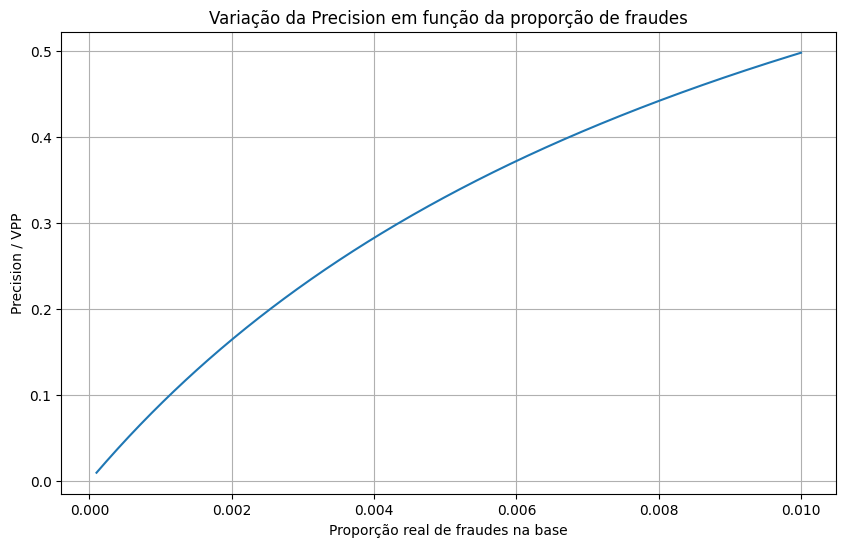

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(proporcoes_fraude, precisions)
plt.xlabel("Proporção real de fraudes na base")
plt.ylabel("Precision / VPP")
plt.title("Variação da Precision em função da proporção de fraudes")
plt.grid(True)
plt.show()

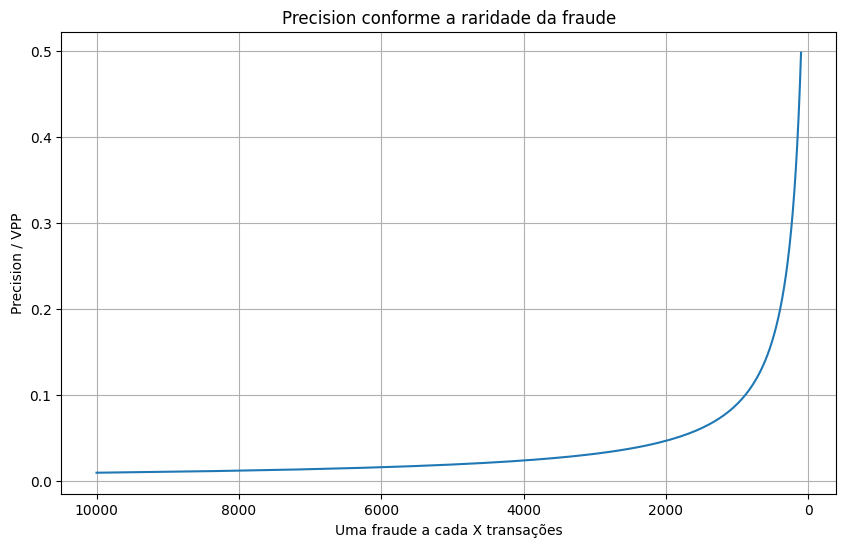

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(1 / proporcoes_fraude, precisions)
plt.xlabel("Uma fraude a cada X transações")
plt.ylabel("Precision / VPP")
plt.title("Precision conforme a raridade da fraude")
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()


## G. Análise crítica

Os resultados mostram que o desempenho de um classificador não deve ser avaliado apenas por métricas como sensibilidade e especificidade, principalmente quando o problema envolve classes muito desbalanceadas. No cenário analisado, a fraude é um evento raro, e isso faz com que até uma pequena taxa de falsos positivos gere um grande número de alertas incorretos. Por esse motivo, mesmo um modelo aparentemente eficiente apresenta uma Precision de apenas cerca de 4,67% na proporção original de 1 fraude a cada 2.000 transações.

Esse resultado reforça a importância de considerar os impactos práticos da decisão automatizada. Em uma instituição financeira, falsos negativos significam fraudes que passam despercebidas, enquanto falsos positivos podem causar bloqueios indevidos, insatisfação dos clientes e aumento da demanda por análise manual. Assim, o modelo não deve ser usado de forma isolada, mas sim calibrado conforme o nível de risco aceitável e integrado a uma política de decisão mais ampla, que considere diferentes limiares de classificação de acordo com o perfil e o contexto de cada transação.




## H. Conclusão

O exercício mostrou a importância do Teorema de Bayes em problemas de classificação probabilística. Ele evidencia que a chance de uma transação realmente ser fraude, depois de ser classificada como suspeita pelo modelo, depende muito da proporção real de fraudes existente na base de dados.

No cenário original, mesmo com uma sensibilidade de 98% e uma especificidade de 99%, o Valor Preditivo Positivo foi de aproximadamente 4,67%. Isso mostra que, em bases muito desbalanceadas, a frequência do evento raro tem grande influência na interpretação dos resultados. Ou seja, mesmo um modelo com boas métricas técnicas pode gerar muitos alertas falsos quando a ocorrência real de fraude é baixa.

